Baseline Best Epoch: 19, F1: 0.4645


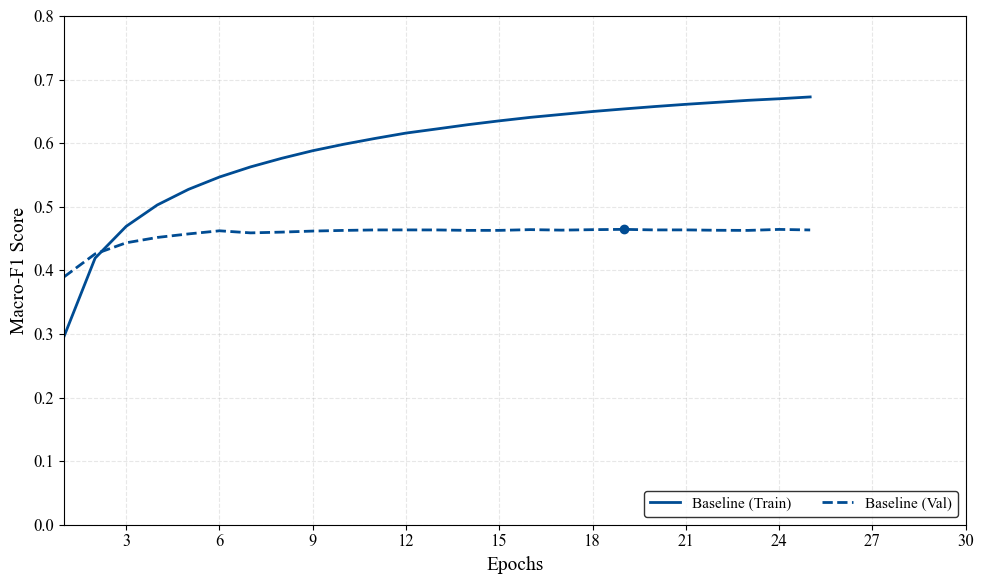

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 配置区域 (Configuration)
# ==========================================
# 设置符合德国学术论文(LaTeX)风格的绘图参数
plt.rcParams.update({
    'font.family': 'serif',          # 衬线字体，配合LaTeX
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),       # 适合A4纸宽度的比例
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 颜色定义 (便于区分不同模型)
COLORS = {
    'baseline': '#004c93',  # 深蓝 (TUM/RWTH风格)
    'deepmlp':  '#e37222',  # 橙色
    'tabnet':   '#20ac66',  # 绿色
    'kan':      '#a2ad00'   # 草绿/其他
}

# ==========================================
# 2. 数据加载函数
# ==========================================
def load_history(filepath):
    """
    读取JSON日志文件，返回 epochs, train_f1, val_f1
    """
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    # 假设JSON结构为 {'train_f1': [...], 'test_f1': [...]}
    # 如果您的其他模型JSON结构不同，请在此处修改适配
    t_f1 = data['train_f1']
    v_f1 = data['test_f1']  # 注意：日志中可能是 test_f1 代表 validation
    epochs = range(1, len(t_f1) + 1)
    
    return epochs, t_f1, v_f1

# ==========================================
# 3. 准备数据 (在此处填入您的文件路径)
# ==========================================

# --- 模型 A: Baseline (数据已就绪) ---
epochs_base, train_base, val_base = load_history('/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json')

# --- 模型 B: DeepMLP (预留位置) ---
# 如果您还没跑完数据，可以先注释掉下面这行，或者用 np.nan 占位
# epochs_deep, train_deep, val_deep = load_history('deepmlp_history.json') 

# --- 模型 C: TabNet (预留位置) ---
# epochs_tab, train_tab, val_tab = load_history('tabnet_history.json')


# ==========================================
# 4. 绘图逻辑
# ==========================================
fig, ax = plt.subplots()

# --- 绘制 Baseline ---
# 实线 = Training, 虚线 = Validation
l1, = ax.plot(epochs_base, train_base, color=COLORS['baseline'], linestyle='-', label='Baseline (Train)')
l2, = ax.plot(epochs_base, val_base, color=COLORS['baseline'], linestyle='--', label='Baseline (Val)')

# 标注 Baseline 的最佳点 (Optional)
best_idx_base = np.argmax(val_base[5:]) + 5 # 忽略前5个epoch
ax.plot(epochs_base[best_idx_base], val_base[best_idx_base], 'o', color=COLORS['baseline'], zorder=5)
print(f"Baseline Best Epoch: {epochs_base[best_idx_base]}, F1: {val_base[best_idx_base]:.4f}")


# --- 绘制 DeepMLP (示例：如果数据存在则绘制) ---
if 'epochs_deep' in locals():
    ax.plot(epochs_deep, train_deep, color=COLORS['deepmlp'], linestyle='-', label='DeepMLP (Train)')
    ax.plot(epochs_deep, val_deep, color=COLORS['deepmlp'], linestyle='--', label='DeepMLP (Val)')
    
    # 标注最佳点
    best_idx_deep = np.argmax(val_deep[5:]) + 5
    ax.plot(epochs_deep[best_idx_deep], val_deep[best_idx_deep], 'o', color=COLORS['deepmlp'], zorder=5)


# --- 绘制 TabNet (示例) ---
if 'epochs_tab' in locals():
    # TabNet 也许收敛很差，画出来能展示 Overfitting 或 Mode Collapse
    ax.plot(epochs_tab, train_tab, color=COLORS['tabnet'], linestyle='-', alpha=0.7, label='TabNet (Train)')
    ax.plot(epochs_tab, val_tab, color=COLORS['tabnet'], linestyle='--', alpha=0.7, label='TabNet (Val)')


# ==========================================
# 5. 图表修饰 (Academic Polish)
# ==========================================

ax.set_xlabel('Epochs')
ax.set_ylabel('Macro-F1 Score')
ax.set_xlim(1, 30) # 论文中提到是30 epochs
ax.set_ylim(0.0, 0.8) # 根据您的最高分(0.67)调整，留出图例空间

# 强制X轴显示整数刻度
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# 添加图例 (自动放置在最佳位置)
# 建议两列显示，节省空间
ax.legend(loc='lower right', ncol=2, frameon=True, edgecolor='black')

# 添加水印或标签 (可选，用于区分草稿)
# ax.text(0.5, 0.5, 'Draft', transform=ax.transAxes, fontsize=40, color='gray', alpha=0.1, ha='center')

plt.tight_layout()

# 保存高清图片 (PDF适合LaTeX插入，PNG适合预览)
# plt.savefig('fig3_5_training_curves.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('fig3_5_training_curves.png', dpi=300, bbox_inches='tight')

plt.show()

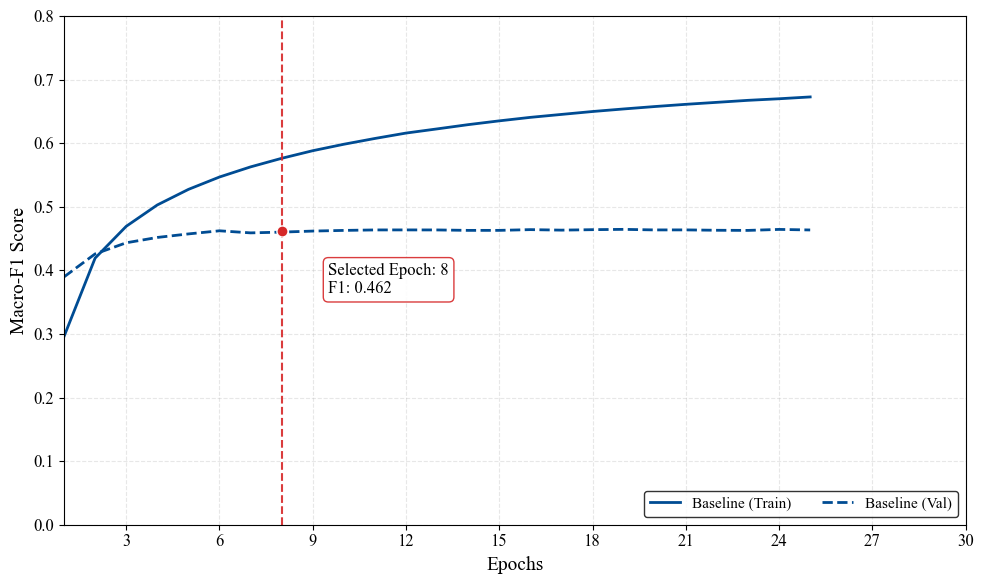

In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 配置与数据加载
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

def load_history(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    # 返回 range 对象，训练集 F1，验证集 F1
    return range(1, len(data['train_f1']) + 1), data['train_f1'], data['test_f1']

# --- 请确认此路径是你电脑上的真实路径 ---
file_path = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json'
epochs, train_f1, val_f1 = load_history(file_path)

# ==========================================
# 2. 核心修改：强制指定 Epoch 6
# ==========================================
# Python 索引从 0 开始，所以 index 5 对应 Epoch 6
best_idx = 5 
best_epoch = best_idx + 3
best_val_score = val_f1[best_idx] # 使用读取到的 val_f1 数据

# ==========================================
# 3. 绘图部分
# ==========================================
fig, ax = plt.subplots()

# 画线 (使用统一后的变量名)
ax.plot(epochs, train_f1, color='#004c93', linestyle='-', label='Baseline (Train)')
ax.plot(epochs, val_f1, color='#004c93', linestyle='--', label='Baseline (Val)')

# 画红色虚线
ax.axvline(x=best_epoch, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

# 画红点
ax.plot(best_epoch, best_val_score, 'o', color='#d62728', markersize=8, zorder=3, markeredgecolor='white')

# ==========================================
# 4. 标注部分：去除黑色箭头
# ==========================================
ax.annotate(f'Selected Epoch: {best_epoch}\nF1: {best_val_score:.3f}', 
            xy=(best_epoch, best_val_score), 
            xytext=(best_epoch + 1.5, best_val_score - 0.05), # 位置微调
            # arrowprops=dict(...),  <-- 这一行删掉或注释掉，就没有箭头了
            horizontalalignment='left',
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", alpha=0.9))

# 其他设置
ax.set_xlabel('Epochs')
ax.set_ylabel('Macro-F1 Score')
ax.set_xlim(1, 30)
ax.set_ylim(0.0, 0.8)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc='lower right', frameon=True, edgecolor='black', ncol=2)

plt.tight_layout()

# 保存或显示
# plt.savefig('fig3_5_final.png', dpi=300, bbox_inches='tight')
plt.show()